<a href="https://colab.research.google.com/github/Swasthika3/DL-24BAD121-/blob/main/EXNO_3_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1553s 9us/step

Original Dataset:
Training images : (50000, 32, 32, 3)
Training labels : (50000, 1)
Testing images  : (10000, 32, 32, 3)
Testing labels  : (10000, 1)

After Splitting:
Training data   : (45000, 32, 32, 3)
Validation data : (5000, 32, 32, 3)
Testing data    : (10000, 32, 32, 3)


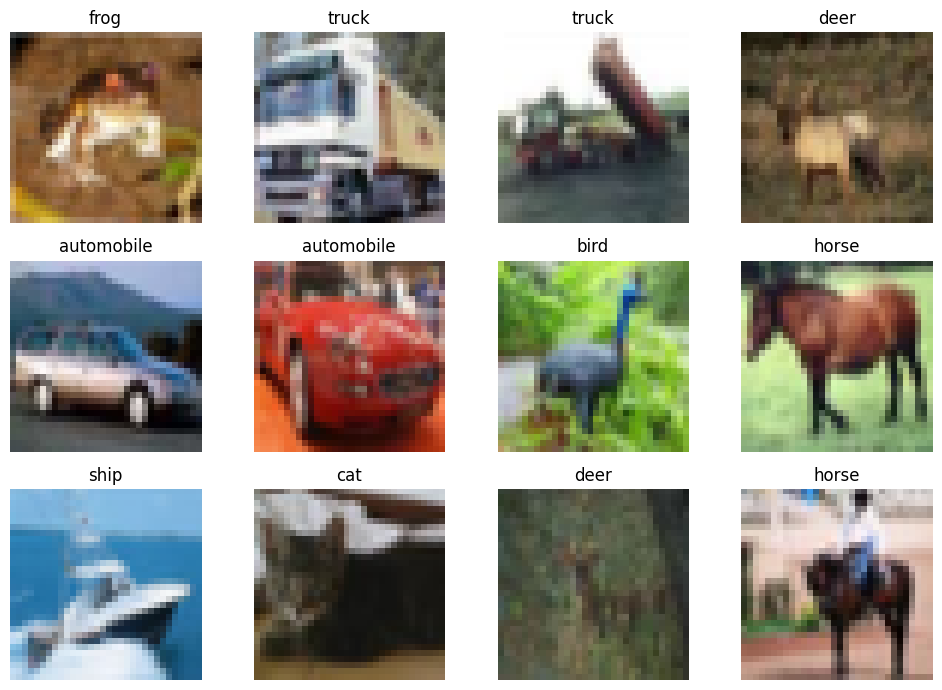

In [1]:
# ============================================================
# EXPERIMENT NO: 3
# TASK A: DATASET PREPARATION
# Student Roll No:SWASTHIKA M
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Check TensorFlow version
print("TensorFlow Version:", tf.__version__)

# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("\nOriginal Dataset:")
print("Training images :", x_train.shape)
print("Training labels :", y_train.shape)
print("Testing images  :", x_test.shape)
print("Testing labels  :", y_test.shape)

# Convert pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Convert labels from 2D to 1D
y_train = y_train.flatten()
y_test = y_test.flatten()

# Split training data into training and validation sets
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("\nAfter Splitting:")
print("Training data   :", x_train.shape)
print("Validation data :", x_val.shape)
print("Testing data    :", x_test.shape)

# Display sample images
plt.figure(figsize=(10, 7))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
# ============================================================
# TASK B: CNN MODEL IMPLEMENTATION

print("SWASTHIKA M 24BAD121")

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Create CNN model
model = Sequential([

    # Convolution Layer 1
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    # Max Pooling Layer 1
    MaxPooling2D((2, 2)),

    # Convolution Layer 2
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Max Pooling Layer 2
    MaxPooling2D((2, 2)),

    # Convolution Layer 3
    Conv2D(
        128,
        (3, 3),
        activation='relu'
    ),

    # Max Pooling Layer 3
    MaxPooling2D((2, 2)),

    # Convert feature maps into vector
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output Layer - 10 CIFAR-10 classes
    Dense(10, activation='softmax')
])

# Display model architecture
model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nCNN model compiled successfully!")

SWASTHIKA M 24BAD121


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)


CNN model compiled successfully!


In [6]:
# ============================================================
# TASK C: MODEL TRAINING AND EVALUATION
# Student Roll No: YOUR_ROLL_NO
print("SWASTHIKA M 24BAD121")

# Number of epochs
EPOCHS = 15

# Batch size
BATCH_SIZE = 64

# Train the CNN model
history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

SWASTHIKA M 24BAD121
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.7988 - loss: 0.5766 - val_accuracy: 0.7396 - val_loss: 0.8348
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.8064 - loss: 0.5553 - val_accuracy: 0.7344 - val_loss: 0.8357
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 129ms/step - accuracy: 0.8127 - loss: 0.5317 - val_accuracy: 0.7268 - val_loss: 0.8651
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 96ms/step - accuracy: 0.8181 - loss: 0.5164 - val_accuracy: 0.7412 - val_loss: 0.8444
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 91ms/step - accuracy: 0.8254 - loss: 0.4930 - val_accuracy: 0.7192 - val_loss: 0.9484
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 89ms/step - accuracy: 0.8246 - loss: 0.4895 - val_accuracy: 0.7278 - val_loss: 0.8808
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 90ms/step - accuracy: 0.8327 - loss: 0.4664 - val_accuracy: 0.7330 - val_loss: 0.9030
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 

In [7]:
# Evaluate model using testing dataset

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("====================================")
print("FINAL MODEL PERFORMANCE")
print("====================================")

print("Testing Loss     :", test_loss)
print("Testing Accuracy :", test_accuracy)
print("Testing Accuracy (%):", test_accuracy * 100)

FINAL MODEL PERFORMANCE
Testing Loss     : 1.0545289516448975
Testing Accuracy : 0.7231000065803528
Testing Accuracy (%): 72.31000065803528


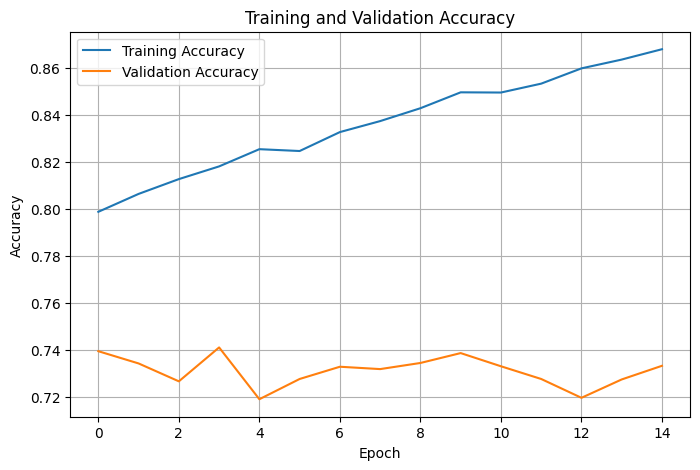

In [8]:
# ============================================================
# ACCURACY VS EPOCH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()
plt.grid(True)

plt.show()

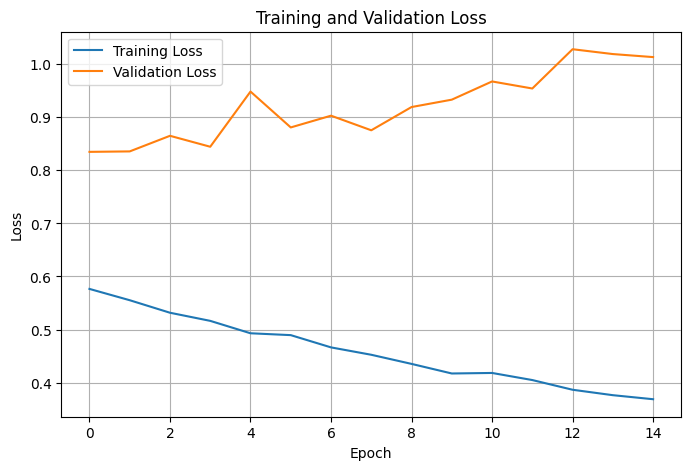

In [9]:
# ============================================================
# LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.grid(True)

plt.show()

In [10]:
# ============================================================
# TASK D: PERFORMANCE ANALYSIS
print("SWASTHIKA M 24BAD121")
from sklearn.metrics import accuracy_score

# Generate predictions
y_probability = model.predict(x_test, verbose=0)

# Convert probability into class number
y_pred = np.argmax(y_probability, axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Classification Accuracy:",
      accuracy)

print("Classification Accuracy (%):",
      accuracy * 100)

SWASTHIKA M 24BAD121
Classification Accuracy: 0.7231
Classification Accuracy (%): 72.31


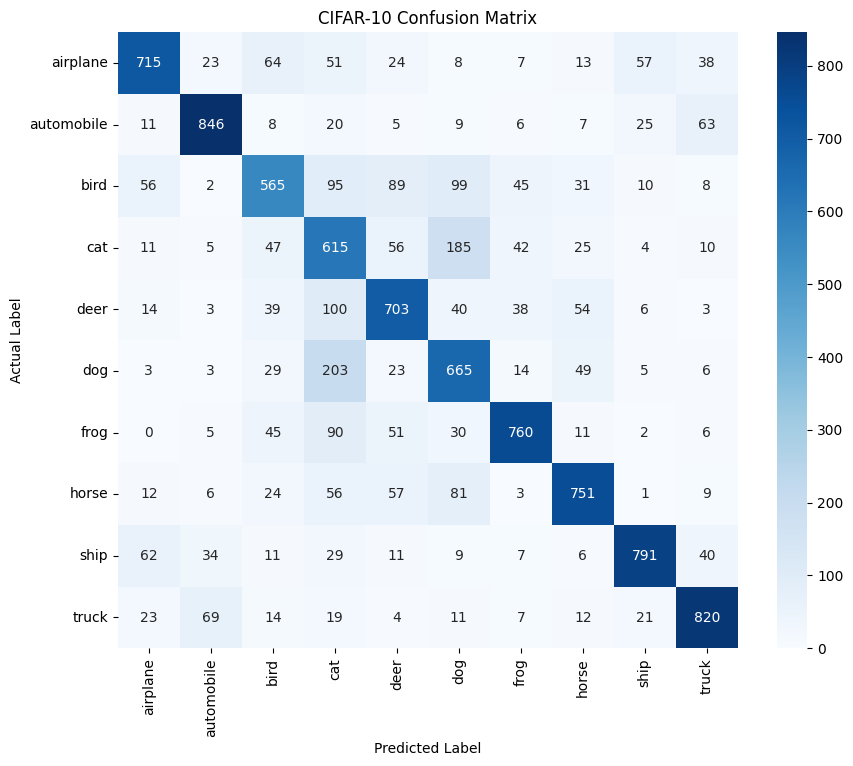

In [11]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("CIFAR-10 Confusion Matrix")

plt.show()

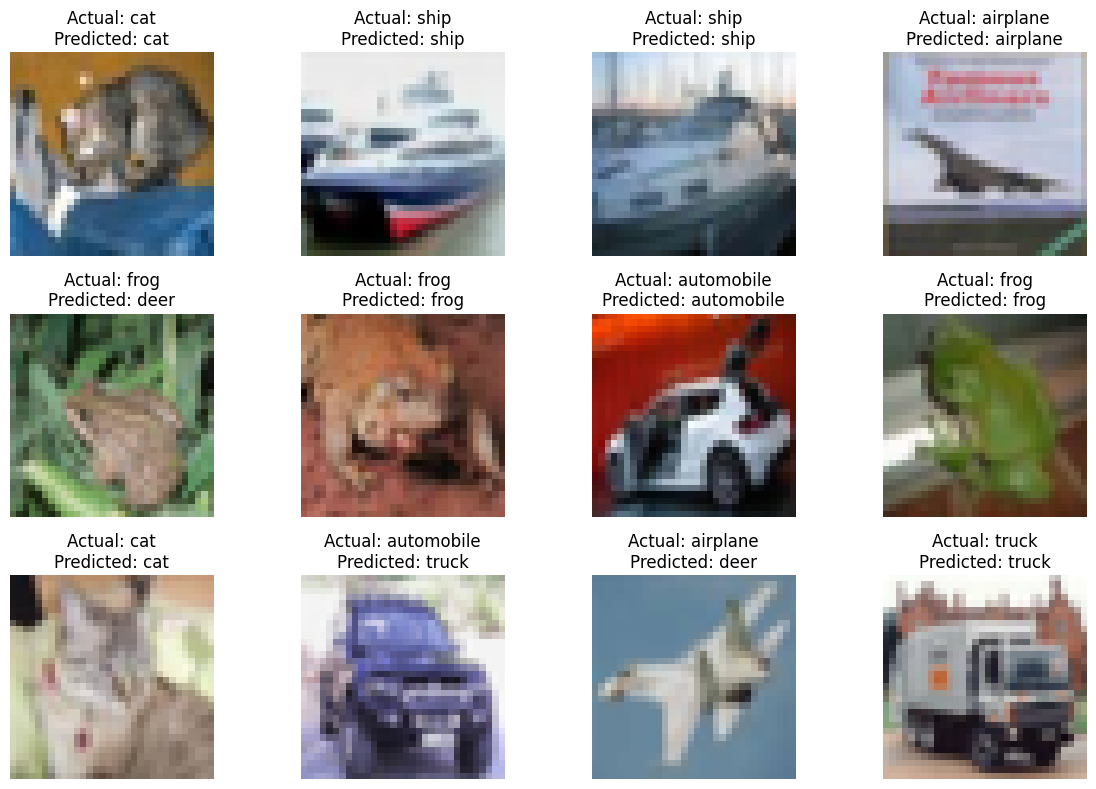

In [12]:
# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

plt.figure(figsize=(12, 8))

for i in range(12):

    predicted_class = y_pred[i]
    actual_class = y_test[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    plt.title(
        "Actual: " + class_names[actual_class] +
        "\nPredicted: " + class_names[predicted_class]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Total Misclassified Images: 2769
Total Correctly Classified Images: 7231


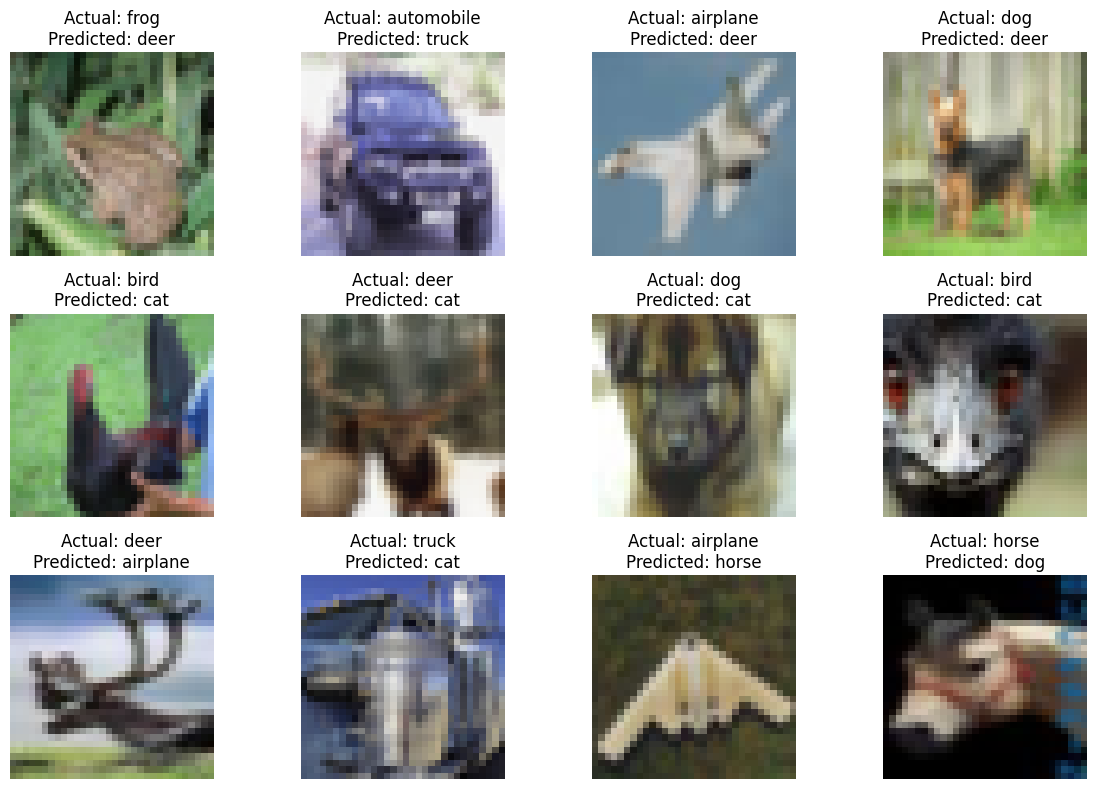

In [13]:
# ============================================================
# MISCLASSIFIED IMAGES
# ============================================================

# Find incorrectly classified images
misclassified = np.where(y_pred != y_test)[0]

print("Total Misclassified Images:",
      len(misclassified))

print("Total Correctly Classified Images:",
      len(y_test) - len(misclassified))

# Display first 12 misclassified images
plt.figure(figsize=(12, 8))

for i in range(min(12, len(misclassified))):

    index = misclassified[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[index])

    plt.title(
        "Actual: " + class_names[y_test[index]] +
        "\nPredicted: " + class_names[y_pred[index]]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()